# EDA — Hippo Academy YouTube Dataset
> By Qiqi & Wildan (Gabungan)
>
> Notebook ini memuat data dari output preprocessing (`hippo_academy_clean.csv`)

## 1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline 

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Data

In [20]:
import os
print(os.getcwd())
df = pd.read_csv('../../data/processed/youtube_cleaned.csv')
print(f"Shape: {df.shape}")
df.head()

/run/media/rizqimaulidiyah/7542d4da-568c-4bbf-b867-1295fe534e4e/Capstone-project/Model-Prediksi-dan-Diagnosa-Penurunan-Views-YouTube-Berbasis-Machine-Learning/notebooks/preparation
Shape: (1988, 18)


,video_title,duration,engaged_views,youtube_premium_idr,estimated_doubleclick_revenue_idr,rpm_idr,hours_streamed,chat_messages,views,video_id,ts1_views,publish_time_wib,avg_view_duration_sec,publish_date,publish_hour,is_viral,views_log,ad_impressions_log
0,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM...",600.0,7225.0,616.644,0.0,0.000,0.1998,0.0,7225.0,L7ZI56pInIg,0.0,19:15:06,308,2026-05-08,19,0,8.885441,0.000000
1,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...,600.0,9831.0,196.718,0.0,0.000,0.1998,0.0,9831.0,7UmhyS2pDQA,0.0,11:15:06,281,2026-05-08,11,0,9.193398,7.678326
2,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...,600.0,4177.0,285.101,0.0,5538.515,0.1998,2.0,4177.0,jWmDRjojWLk,0.0,07:15:06,240,2026-05-07,7,0,8.337588,8.257126
3,HINA INDONESIA MISKIN! RINGGIT BENAR-BENAR TAK...,600.0,4948.0,306.240,0.0,6910.105,0.1999,0.0,4948.0,E7B26wGxjZU,1215.0,07:15:06,278,2026-05-06,7,0,8.506941,8.330140
4,PETRONAS BANGKRUT?! DPR DAN RAJA MALAYSIA NGAM...,600.0,7111.0,516.474,0.0,5446.554,0.1998,0.0,7111.0,ixSFPgKN62w,6377.0,15:15:06,278,2026-05-06,15,0,8.869539,8.858226


## 3. Data Overview

In [21]:
print(f"Shape: {df.shape}")
print(f"\nTipe Data:")
print(df.dtypes)
print(f"\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values!")

Shape: (1988, 18)

Tipe Data:
video_title                              str
duration                             float64
engaged_views                        float64
youtube_premium_idr                  float64
estimated_doubleclick_revenue_idr    float64
rpm_idr                              float64
hours_streamed                       float64
chat_messages                        float64
views                                float64
video_id                                 str
ts1_views                            float64
publish_time_wib                         str
avg_view_duration_sec                  int64
publish_date                             str
publish_hour                           int64
is_viral                               int64
views_log                            float64
ad_impressions_log                   float64
dtype: object

Missing Values:
Tidak ada missing values!


## 4. Descriptive Statistics

In [22]:
df.describe().round(2)

,duration,engaged_views,youtube_premium_idr,estimated_doubleclick_revenue_idr,rpm_idr,hours_streamed,chat_messages,views,ts1_views,avg_view_duration_sec,publish_hour,is_viral,views_log,ad_impressions_log
count,1988.00,1988.00,1988.00,1988.0,1988.00,1988.00,1988.00,1988.00,1988.00,1988.00,1988.00,1988.0,1988.00,1988.00
mean,585.25,25853.63,1711.28,0.0,3358.78,0.20,0.40,26326.20,23575.51,211.90,13.78,0.1,9.57,8.76
std,202.12,43628.14,3956.57,0.0,1628.85,0.03,1.13,43817.45,41028.55,50.91,4.35,0.3,1.06,2.40
min,14.00,296.00,0.00,0.0,0.00,0.00,0.00,296.00,0.00,25.00,2.00,0.0,5.69,0.00
25%,534.00,6700.25,271.21,0.0,2474.52,0.19,0.00,6981.50,4329.75,191.00,10.00,0.0,8.85,8.48
50%,581.00,12492.00,616.64,0.0,3178.53,0.20,0.00,12900.00,9204.00,216.00,15.00,0.0,9.47,9.14
75%,630.00,26413.25,1650.70,0.0,4099.05,0.21,0.00,27201.25,23544.50,240.00,18.00,0.0,10.21,9.91
max,3485.00,827102.00,86603.11,0.0,30289.96,0.42,17.00,827102.00,386070.00,716.00,23.00,1.0,13.63,13.36


## 5. Distribusi Views
Histogram dan boxplot untuk melihat sebaran views.

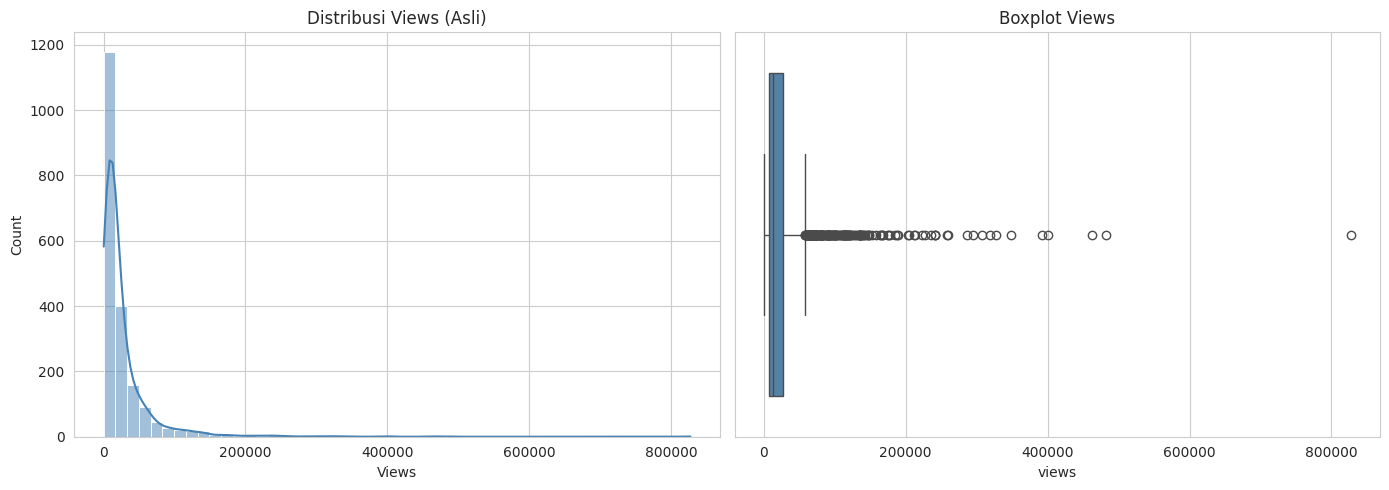

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['views'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Views (Asli)')
axes[0].set_xlabel('Views')

sns.boxplot(x=df['views'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot Views')
plt.tight_layout()
plt.savefig('../../data/processed/eda_views_dist.png', dpi=150)
plt.show()

### 5.1 Perbandingan Sebelum & Sesudah Log Transform

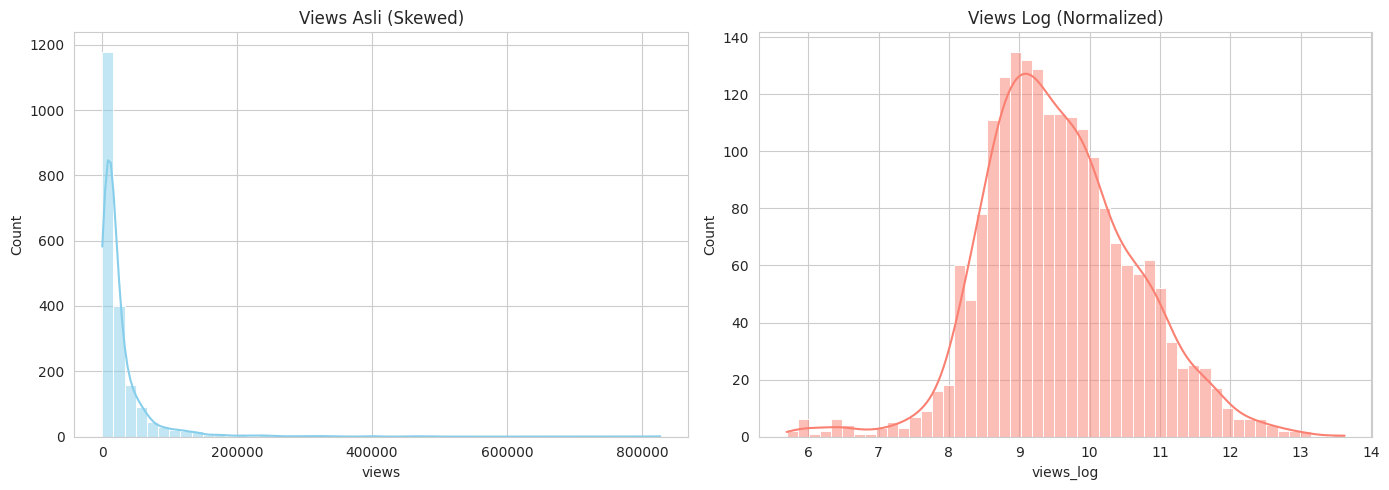

In [24]:
if 'views_log' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df['views'], bins=50, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Views Asli (Skewed)')
    sns.histplot(df['views_log'], bins=50, kde=True, ax=axes[1], color='salmon')
    axes[1].set_title('Views Log (Normalized)')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_views_log_compare.png', dpi=150)
    plt.show()

## 6. Analisis Outlier (IQR Flagging)
Video viral di-flag, **bukan dihapus**.

Distribusi is_viral:
is_viral
0    1785
1     203


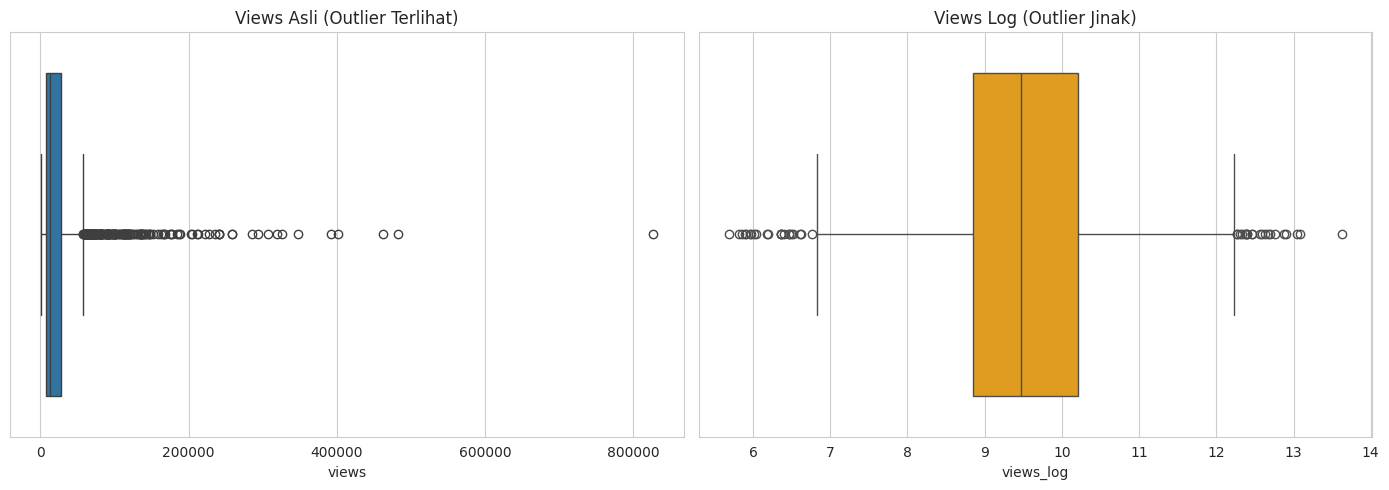

In [25]:
if 'is_viral' in df.columns:
    print(f"Distribusi is_viral:\n{df['is_viral'].value_counts().to_string()}")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(x=df['views'], ax=axes[0])
    axes[0].set_title('Views Asli (Outlier Terlihat)')
    if 'views_log' in df.columns:
        sns.boxplot(x=df['views_log'], ax=axes[1], color='orange')
        axes[1].set_title('Views Log (Outlier Jinak)')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_outlier_flagging.png', dpi=150)
    plt.show()

### 6.1 Outlier per Kategori Metrik

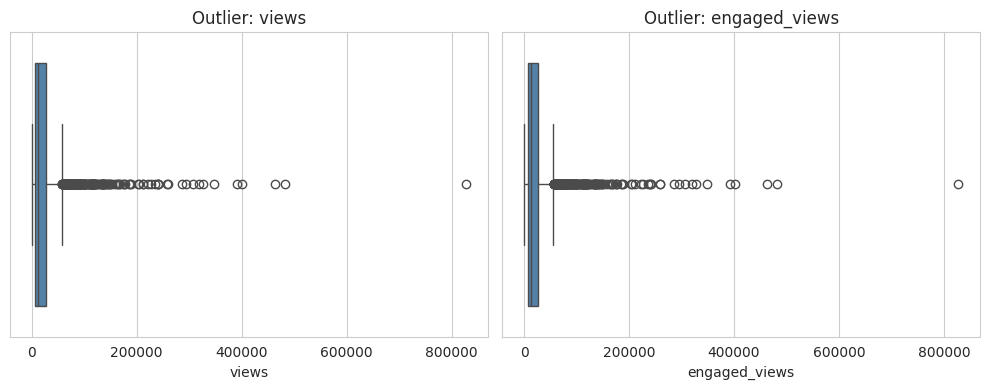

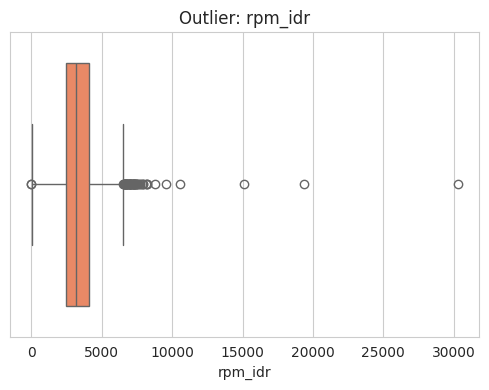

In [26]:
perf_cols = [c for c in ['views','watch_time_hours','engaged_views'] if c in df.columns]
if perf_cols:
    fig, axes = plt.subplots(1, len(perf_cols), figsize=(5*len(perf_cols), 4))
    if len(perf_cols) == 1: axes = [axes]
    for ax, col in zip(axes, perf_cols):
        sns.boxplot(x=df[col], ax=ax, color='steelblue')
        ax.set_title(f'Outlier: {col}')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_outlier_categories.png', dpi=150)
    plt.show()

# Revenue & monetization
rev_cols = [c for c in ['estimated_revenue_idr','yt_ad_revenue_idr','cpm_idr','rpm_idr'] if c in df.columns]
if rev_cols:
    fig, axes = plt.subplots(1, len(rev_cols), figsize=(5*len(rev_cols), 4))
    if len(rev_cols) == 1: axes = [axes]
    for ax, col in zip(axes, rev_cols):
        sns.boxplot(x=df[col], ax=ax, color='coral')
        ax.set_title(f'Outlier: {col}')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_outlier_revenue.png', dpi=150)
    plt.show()

# Retensi & efisiensi
ret_cols = [c for c in ['avg_pct_viewed','impressions_ctr_pct'] if c in df.columns]
if ret_cols:
    fig, axes = plt.subplots(1, len(ret_cols), figsize=(5*len(ret_cols), 4))
    if len(ret_cols) == 1: axes = [axes]
    for ax, col in zip(axes, ret_cols):
        sns.boxplot(x=df[col], ax=ax, color='seagreen')
        ax.set_title(f'Outlier: {col}')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_outlier_retention.png', dpi=150)
    plt.show()

### 6.2 Log Transform: Watch Time & Engaged Views

In [27]:
log_cols = [c for c in ['watch_time_hours','engaged_views'] if c in df.columns]
for col in log_cols:
    log_col = f'{col}_log'
    if log_col in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(df[col], bins=30, ax=axes[0], kde=True, color='skyblue')
        axes[0].set_title(f'{col} (Original)')
        sns.histplot(df[log_col], bins=30, ax=axes[1], kde=True, color='salmon')
        axes[1].set_title(f'{log_col} (Log)')
        plt.tight_layout()
        plt.savefig(f'../../data/processed/eda_{col}_log.png', dpi=150)
        plt.show()

## 7. Correlation Heatmap

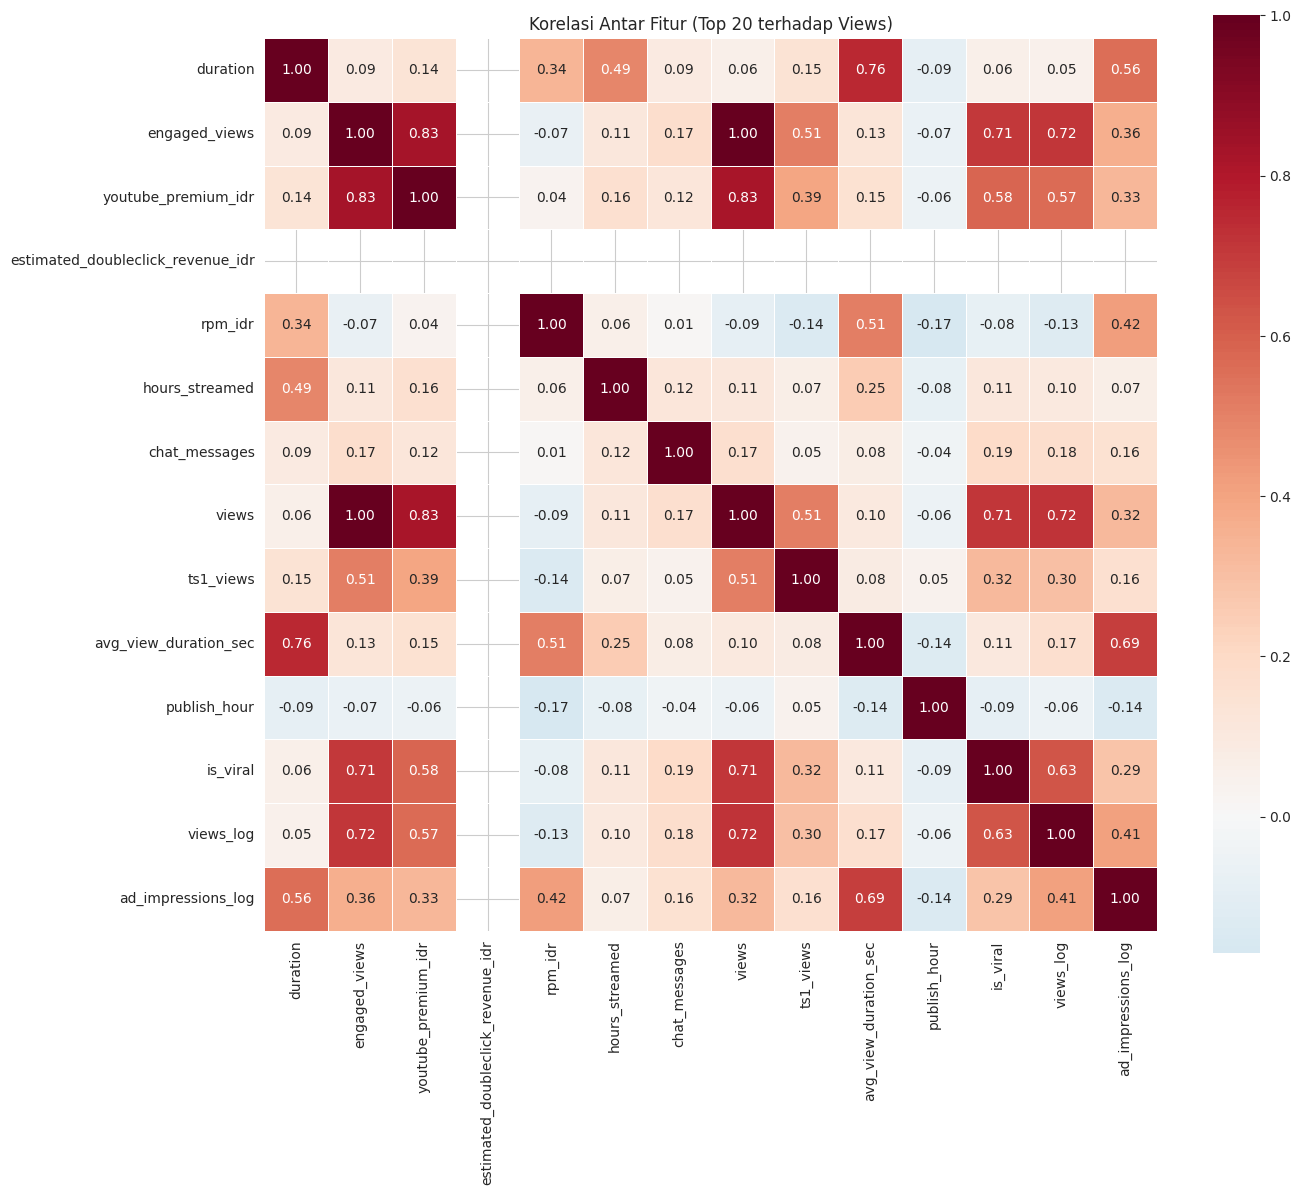

In [28]:
num_cols = df.select_dtypes(include='number').columns
if len(num_cols) > 20:
    corr_all = df[num_cols].corr()
    top_corr = corr_all['views'].abs().sort_values(ascending=False).head(20).index
    num_cols = top_corr

plt.figure(figsize=(14, 12))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Korelasi Antar Fitur (Top 20 terhadap Views)')
plt.tight_layout()
plt.savefig('../../data/processed/eda_correlation_heatmap.png', dpi=150)
plt.show()

## 8. Tren Bulanan Views

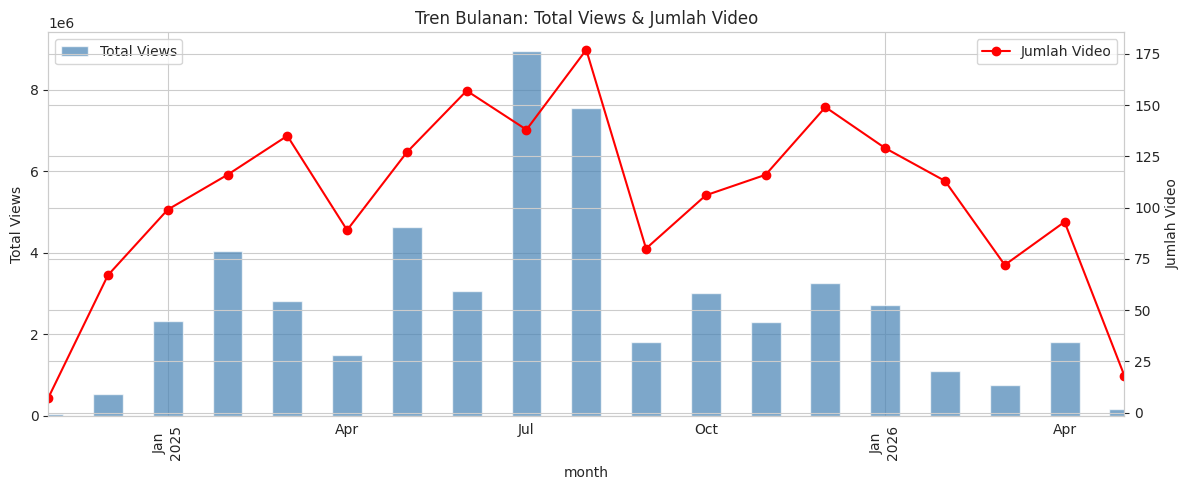

In [29]:
if 'publish_date' in df.columns:
    df['publish_date_dt'] = pd.to_datetime(df['publish_date'], errors='coerce')
    df['month'] = df['publish_date_dt'].dt.to_period('M')
    monthly = df.groupby('month')['views'].agg(['sum','mean','count'])

    fig, ax1 = plt.subplots(figsize=(12, 5))
    monthly['sum'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7, label='Total Views')
    ax1.set_ylabel('Total Views')
    ax1.set_title('Tren Bulanan: Total Views & Jumlah Video')

    ax2 = ax1.twinx()
    monthly['count'].plot(kind='line', ax=ax2, color='red', marker='o', label='Jumlah Video')
    ax2.set_ylabel('Jumlah Video')

    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_monthly_trend.png', dpi=150)
    plt.show()

## 9. Top 10 Video by Views

In [30]:
top_cols = [c for c in ['video_title','views','publish_date'] if c in df.columns]
if top_cols:
    print(df.nlargest(10, 'views')[top_cols].to_string(index=False))

                                                                                    video_title    views publish_date
         MALAYSIA INGATKAN MYANMAR JANGAN MAIN-MAIN SAMA INDONESIA MEREKA PUNYA TNI SANGAT KUAT 827102.0   2025-07-09
PELAJARAN BUAT MUSUH INDONESIA JUNTA MYANMAR KOCAR-KACIR KE THAILAND DIGEMPUR HABIS PEMBERONTAK 482310.0   2025-07-16
  BIKIN HEBOHINDONESIA DI PANGGIL IRAN SAAT ADU RUDALPRABOWO JADI KUNCI PERDAMAIAN TIMUR TENGAH 462912.0   2025-07-03
  PERINGATAN TERAKHIR MYANMAR PRABOWO TOLAK PERANG TAPI JIKA TERPAKSA KITA TIDAK AKAN MAIN-MAIN 401146.0   2025-07-08
SEBUT TENTARA TERKUAT DI DUNIA, MALAYSIA TAK DI UNDANG BASTILLE DAYINDONESIA KIRIM 500 PERSONEL 391881.0   2025-07-07
    ASEAN TERPUKAU AKSI JET TEMPUR & TNI BIKIN TENTARA PERANCIS GEMETAR INDONESIA GUNCANG EROPA 348112.0   2025-07-13
     BIKIN MERINDING REOG TAMPIL GAGAH PUKAU PARA JENDERAL EROPA DI ACARA BASTILLE DAY PERANCIS 326805.0   2025-07-14
  GANYANG MYANMARINDONESIA ANCAM OPERASI MILITER KE MYAN

## 10. CTR vs Views

In [31]:
if 'ctr' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(df['ctr'], df['views'], alpha=0.5,
                         c=df.get('is_viral', 0), cmap='coolwarm',
                         edgecolors='none', s=30)
    ax.set_xlabel('CTR')
    ax.set_ylabel('Views')
    ax.set_title('CTR vs Views (warna = is_viral)')
    plt.colorbar(scatter, label='is_viral')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_ctr_vs_views.png', dpi=150)
    plt.show()

## 11. Topic Cluster Analysis

In [32]:
if 'topic_cluster' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    tc = df['topic_cluster'].value_counts()
    tc.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Jumlah Video per Topic')
    axes[0].set_xlabel('Count')

    df.groupby('topic_cluster')['views'].median().sort_values().plot(
        kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Median Views per Topic')
    axes[1].set_xlabel('Median Views')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_topic_cluster.png', dpi=150)
    plt.show()

## 12. Performance Class Distribution

In [33]:
if 'performance_class' in df.columns:
    class_order = ['rendah','sedang','bagus','sangat_bagus','viral']
    pc = df['performance_class'].value_counts().reindex(class_order)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ['#e74c3c','#f39c12','#27ae60','#2980b9','#8e44ad']
    pc.plot(kind='bar', ax=axes[0], color=colors)
    axes[0].set_title('Distribusi Performance Class')
    axes[0].set_ylabel('Count')

    pc.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%')
    axes[1].set_title('Proporsi Performance Class')
    axes[1].set_ylabel('')
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_performance_class.png', dpi=150)
    plt.show()

## 13. Durasi vs Views

In [34]:
if 'duration_bucket' in df.columns:
    order = ['shorts (<1 mnt)','pendek (1-3 mnt)','medium (3-7 mnt)',
             'panjang (7-15 mnt)','sangat panjang (>15 mnt)']
    existing_order = [o for o in order if o in df['duration_bucket'].values]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x='duration_bucket', y='views', order=existing_order, ax=ax)
    ax.set_title('Views per Duration Bucket')
    ax.set_xlabel('Duration Bucket')
    ax.set_ylabel('Views')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig('../../data/processed/eda_duration_vs_views.png', dpi=150)
    plt.show()

## 14. Kesimpulan

### Temuan Utama:
1. **Distribusi views sangat skewed** — mayoritas video memiliki views rendah, sedikit video viral mendominasi
2. **IQR flagging** mendeteksi video viral tanpa menghapus data berharga
3. **Log transform** menjinakkan outlier dan membuat distribusi lebih normal
4. **Korelasi tinggi** antara views, watch_time_hours, engaged_views (expected)
5. **CTR** memiliki pengaruh moderat terhadap views
6. **Durasi video** mempengaruhi views — video medium (3-7 menit) cenderung optimal
7. **Topic cluster** menunjukkan perbedaan performa antar tema konten